This notebook is intened same normative deviation approach but for slow-4 and slow-5 peak frequency (or frequency sliding approach)

In [5]:
from pathlib import Path
import os


# --- Helper: choose between macOS-style and Windows-style roots ---
def project_path(mac_path_str, win_path_str):
    mac_p = Path(mac_path_str)
    win_p = Path(win_path_str)
    if mac_p.exists():
        return mac_p
    elif win_p.exists():
        return win_p
    else:
        # Neither exists; return mac version but warn
        print(f"WARNING: Neither {mac_p} nor {win_p} exists on this system.")
        return mac_p


project_path_set = project_path(
    "/Users/kaankeskin/projects/FrequencySliding/",
    "C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/"
)

# Set the working directory
os.chdir(project_path_set)

# Check current working directory
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\kaank\OneDrive\Belgeler\GitHub\FrequencySliding


In [6]:
from scipy.io import loadmat
import numpy as np
import pandas as pd

BP = loadmat("./data/output/PF_BP.mat", simplify_cells=True)  # SciPy ≥1.7
# If your SciPy is older, use: loadmat("file.mat", squeeze_me=True, struct_as_record=False)

X_BP = BP["PF_all_slow5"]    # numpy array


# Matrix: rows = subjects, cols = PF_peak entries (360)
BP_PF_peak_mat = np.stack([np.ravel(s["PF_peak"]) for s in X_BP], axis=0)

HC = loadmat("./data/output/PF_HC.mat", simplify_cells=True)  # SciPy ≥1.7
# If your SciPy is older, use: loadmat("file.mat", squeeze_me=True, struct_as_record=False)

X_HC = HC["PF_all_slow5"]    # numpy array

# Matrix: rows = subjects, cols = PF_peak entries (360)
HC_PF_peak_mat = np.stack([np.ravel(s["PF_peak"]) for s in X_HC], axis=0)


In [7]:
# Helper to turn various MATLAB-ish forms into a scalar label
def to_scalar_label(v):
    a = np.asarray(v)
    val = a.item() if a.ndim == 0 else a.ravel()[0]
    if isinstance(val, bytes):
        val = val.decode("utf-8", errors="ignore")
    return val

## BP

# 2) Row IDs from per-subject field if available
row_ids = [to_scalar_label(s.get("subj_id", i)) for i, s in enumerate(X_BP)]

# If there’s also a top-level subj_id vector and you prefer it, uncomment:
# if "subj_id" in data:
#     row_ids = [to_scalar_label(x) for x in np.asarray(data["subj_id"]).ravel()]

# Warn if duplicate IDs
if len(set(row_ids)) != len(row_ids):
    print("Warning: duplicate subj_id values detected.")

# 3) Build labeled matrix
bp_peak = pd.DataFrame(BP_PF_peak_mat, index=row_ids)
bp_peak.index.name = "subj_id"



In [8]:
import re
# 2) Row IDs from per-subject field if available
row_ids = [to_scalar_label(s.get("subj_id", i)) for i, s in enumerate(X_HC)]

pat = re.compile(r'(?<=sub-)\d+(?=\.results\b)')

def shift_ids(ids, offset=8):
    def repl(m):
        n = m.group(0)
        # preserves leading zeros if present
        return f"{int(n) + offset:0{len(n)}d}"
    return [pat.sub(repl, s) for s in ids]

row_ids_plus8 = shift_ids(row_ids, 8)
print(row_ids_plus8[:5])

row_ids_seq43 = [f"sub-{43+i}.results" for i in range(len(row_ids))]

#print(row_ids)
# If there’s also a top-level subj_id vector and you prefer it, uncomment:
# if "subj_id" in data:
#     row_ids = [to_scalar_label(x) for x in np.asarray(data["subj_id"]).ravel()]

# Warn if duplicate IDs
if len(set(row_ids)) != len(row_ids):
    print("Warning: duplicate subj_id values detected.")

# 3) Build labeled matrix
hc_peak = pd.DataFrame(HC_PF_peak_mat, index=row_ids_seq43)
hc_peak.index.name = "subj_id"

df_all = pd.concat([bp_peak, hc_peak])
print(df_all)

df_all.to_csv("./data/output/slow5_baseline.csv", index=True, index_label="subj_id")

['sub-43.results', 'sub-44.results', 'sub-45.results', 'sub-46.results', 'sub-48.results']
                     0         1         2         3         4         5    \
subj_id                                                                      
sub-1.results   0.019796  0.016627  0.019559  0.020946  0.022562  0.021952   
sub-10.results  0.024529  0.019737  0.018985  0.024533  0.020840  0.020028   
sub-11.results  0.017466  0.021583  0.018943  0.022826  0.020522  0.017427   
sub-12.results  0.023034  0.024263  0.019651  0.020025  0.020060  0.021356   
sub-13.results  0.017957  0.021430  0.014905  0.017904  0.017918  0.018037   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  0.016730  0.016742  0.017447  0.021452  0.020759  0.019699   
sub-72.results  0.015923  0.021551  0.023555  0.020038  0.019054  0.016511   
sub-73.results  0.017836  0.022453  0.018578  0.021843  0.021421  0.013928   
sub-74.results  0.019819  0.019206  0.020389  0.018

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"./data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"

# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

# If the file has no header row and just two columns, uncomment:
# ctrl_df = pd.read_csv(ctrl_csv, header=None, names=["transmodal", "unimodal"])

# Ensure we have at least two columns
if ctrl_df.shape[1] < 2:
    raise ValueError("controlregions.csv must have at least two columns (transmodal, unimodal).")

# Normalize column names (optional but convenient)
ctrl_df = ctrl_df.rename(columns=lambda c: str(c).strip().lower())

# Try to find columns by name; fall back to positional
trans_col = next((c for c in ctrl_df.columns if "trans" in c), ctrl_df.columns[0])
uni_col   = next((c for c in ctrl_df.columns if "uni" in c),   ctrl_df.columns[1])

transmask_raw = ctrl_df[trans_col].to_numpy()
unimask_raw   = ctrl_df[uni_col].to_numpy()

# --- Coerce to boolean masks ---
# Treat nonzero & non-null as True
transmask = np.asarray(transmask_raw, dtype=float)
unimask   = np.asarray(unimask_raw, dtype=float)

# If any NaNs, treat as 0
transmask = np.nan_to_num(transmask, nan=0.0)
unimask   = np.nan_to_num(unimask,   nan=0.0)

transmask_bool = transmask.astype(bool)
unimask_bool   = unimask.astype(bool)

# --- Check mask lengths vs df_all columns ---
n_roi_mask = len(transmask_bool)
n_roi_df   = df_all.shape[1]

if n_roi_mask != n_roi_df:
    raise ValueError(
        f"Mask length ({n_roi_mask}) != number of ROI columns in df_all ({n_roi_df}). "
        "We need a mapping or confirmation of ROI order."
    )

# --- Compute subject means across masked ROIs ---
# df_all: subjects × ROIs
MF_transmodal = df_all.loc[:, transmask_bool].mean(axis=1, skipna=True)
MF_unimodal   = df_all.loc[:, unimask_bool].mean(axis=1, skipna=True)

# --- Append to df_all ---
df_all = df_all.copy()
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal
print(df_all)


                       0         1         2         3         4         5  \
subj_id                                                                      
sub-1.results   0.046007  0.046436  0.049072  0.047271  0.047740  0.049068   
sub-10.results  0.046599  0.054025  0.049311  0.048910  0.052254  0.046930   
sub-11.results  0.045156  0.055042  0.052195  0.048349  0.051103  0.046692   
sub-12.results  0.051761  0.050685  0.046196  0.048078  0.045368  0.046809   
sub-13.results  0.044647  0.046281  0.051457  0.048828  0.053062  0.050012   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  0.046791  0.047586  0.049746  0.041303  0.042985  0.042091   
sub-72.results  0.051129  0.054956  0.051520  0.044013  0.052641  0.054269   
sub-73.results  0.049918  0.051949  0.047691  0.054418  0.054433  0.054686   
sub-74.results  0.046970  0.053713  0.056631  0.046747  0.053515  0.058378   
sub-75.results  0.051805  0.053426  0.048301  0.052927  0.049371

In [7]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. Load BP sheet (Excel): has SubjectID, Total Score, Age, Sex
# ------------------------------------------------------------------
bp_subj = pd.read_excel(
    r"./data/raw/BDI_ThreeFactor_MultiSubject.xlsx"
)

# Standardize column names just in case
bp_subj = bp_subj.rename(columns=lambda c: str(c).strip())

# Rename Total Score -> BDI; keep needed columns
bp_use = (
    bp_subj.rename(columns={"Total Score": "BDI"})[["SubjectID", "BDI", "Age", "Sex"]]
    .assign(Group="BP")
)

# ------------------------------------------------------------------
# 2. Load HC participants slice from TSV and drop exclusions
# ------------------------------------------------------------------
df = pd.read_csv(r"E:/BIDS/participants.tsv", sep="\t")

# R slice(35:70) => pandas iloc[34:70] (sub-35..sub-70 inclusive in R)
df_slice = df.iloc[34:70].copy()

exclude_ids = ["sub-54", "sub-39", "sub-58"]
hc_subj = df_slice.loc[~df_slice["participant_id"].isin(exclude_ids)].copy()

# Number of HC subjects kept
n = len(hc_subj)

# ------------------------------------------------------------------
# 3. Build renumbered HC ID list starting at 43
# ------------------------------------------------------------------
start_id = 43
hc_ids_renum = [f"sub-{start_id + i}" for i in range(n)]

# Create HC BDI/demographics DataFrame with renumbered IDs
hc_bdi_renum_df = pd.DataFrame({
    "SubjectID": hc_ids_renum,
    "BDI": pd.to_numeric(hc_subj["BDI"], errors="coerce"),
    "Age": pd.to_numeric(hc_subj["Age"], errors="coerce"),
    "Sex": pd.to_numeric(hc_subj["Sex"], errors="coerce"),
    "Group": "HC",   # one value broadcast to all rows
})

# ------------------------------------------------------------------
# 4. Combine BP + HC into one BDI/demographics table
# ------------------------------------------------------------------
bdi_df = pd.concat([bp_use, hc_bdi_renum_df], axis=0, ignore_index=True)

# Ensure BDI numeric
bdi_df["BDI"] = pd.to_numeric(bdi_df["BDI"], errors="coerce")

# ------------------------------------------------------------------
# 5. Prepare df_all imaging data
#     (Assumes df_all already exists & MF_transmodal / MF_unimodal arrays ready)
# ------------------------------------------------------------------
df_all = df_all.copy()

# Add MF columns if not already present
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal

# Add clean SubjectID (strip ".results")
df_all["SubjectID"] = df_all.index.to_series().str.replace(".results", "", regex=False)

# ------------------------------------------------------------------
# 6. Merge BDI + Age + Sex into df_all by SubjectID
# ------------------------------------------------------------------
df_all = df_all.merge(
    bdi_df,                # has SubjectID, BDI, Age, Sex
    on="SubjectID",
    how="left",
    validate="m:1"         # one demographic row per SubjectID expected
)

# ------------------------------------------------------------------
# 7. Final metrics table with Age & Sex at the end
# ------------------------------------------------------------------
df_metrics = df_all.loc[:, ["SubjectID", "Group","BDI", "MF_transmodal", "MF_unimodal", "Age", "Sex"]].reset_index(drop=True)

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex
0     sub-1    BP   8.0       0.048742     0.048670  56.0  2.0
1    sub-10    BP  30.0       0.049511     0.049423  26.0  2.0
2    sub-11    BP  44.0       0.049096     0.050113  54.0  1.0
3    sub-12    BP  38.0       0.048764     0.049986  40.0  1.0
4    sub-13    BP  22.0       0.047710     0.048379  52.0  2.0
   SubjectID Group  BDI  MF_transmodal  MF_unimodal   Age  Sex
66    sub-71    HC  2.0       0.050255     0.047391  22.0  2.0
67    sub-72    HC  3.0       0.050092     0.049810  31.0  1.0
68    sub-73    HC  0.0       0.050267     0.051367  28.0  1.0
69    sub-74    HC  8.0       0.049634     0.051618  46.0  2.0
70    sub-75    HC  1.0       0.050348     0.050841  20.0  2.0
Shape: (71, 7)
Missing BDI: 1


In [8]:
drop_index=["sub-20", "sub-30","sub-35","sub-36","sub-37","sub-41","sub-42"]
df_metrics = df_metrics[~df_metrics["SubjectID"].isin(drop_index)]

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex
0     sub-1    BP   8.0       0.048742     0.048670  56.0  2.0
1    sub-10    BP  30.0       0.049511     0.049423  26.0  2.0
2    sub-11    BP  44.0       0.049096     0.050113  54.0  1.0
3    sub-12    BP  38.0       0.048764     0.049986  40.0  1.0
4    sub-13    BP  22.0       0.047710     0.048379  52.0  2.0
   SubjectID Group  BDI  MF_transmodal  MF_unimodal   Age  Sex
66    sub-71    HC  2.0       0.050255     0.047391  22.0  2.0
67    sub-72    HC  3.0       0.050092     0.049810  31.0  1.0
68    sub-73    HC  0.0       0.050267     0.051367  28.0  1.0
69    sub-74    HC  8.0       0.049634     0.051618  46.0  2.0
70    sub-75    HC  1.0       0.050348     0.050841  20.0  2.0
Shape: (65, 7)
Missing BDI: 1


In [15]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

df2 = df_metrics.copy()
# Encode Sex to 0/1 if needed (your data are 1/2); choose a reference you prefer.
df2["Sex_bin"] = (df2["Sex"]==2).astype(int)

hc = df2[df2["Group"]=="HC"].copy()
bp = df2[df2["Group"]=="BP"].copy()

for col in ["MF_unimodal","MF_transmodal"]:
    X_hc = sm.add_constant(hc[["Age","Sex_bin"]])
    y_hc = hc[col]
    m = sm.OLS(y_hc, X_hc).fit()

    # Predict expected MF for BP under the HC model
    X_bp = sm.add_constant(bp[["Age","Sex_bin"]], has_constant="add")
    yhat_bp = m.predict(X_bp)

    # Use HC residual SD as normative SD
    resid_sd_hc = m.resid.std(ddof=int(m.df_model)+1)

    bp[f"{col}_adj_zHC"] = (bp[col] - yhat_bp) / resid_sd_hc

bp_adj_subject_devs = bp[["SubjectID","Group","MF_unimodal_adj_zHC","MF_transmodal_adj_zHC"]]
bp_adj_summary = bp[["MF_unimodal_adj_zHC","MF_transmodal_adj_zHC"]].agg(["mean","std","median"])

bp_adj_subject_devs = (
    df2.query("Group == 'BP'")[["SubjectID","Group","BDI","Age","Sex"]]
    .merge(
        bp[["SubjectID","MF_unimodal_adj_zHC","MF_transmodal_adj_zHC"]],
        on="SubjectID", how="left"
    )
    .sort_values("SubjectID")
    .reset_index(drop=True)
)

# Z transform for BDI
bp_adj_subject_devs = bp_adj_subject_devs.dropna(subset=["BDI"])

scaler = StandardScaler()
bp_adj_subject_devs[["z_BDI"]] = scaler.fit_transform(bp_adj_subject_devs[["BDI"]])  # the outcome
bp_adj_subject_devs[["z_Age"]] = scaler.fit_transform(bp_adj_subject_devs[["Age"]])  # the outcome
bp_adj_subject_devs["Sex"] = (bp_adj_subject_devs["Sex"]==2).astype(int)

print(bp_adj_subject_devs)

# Design Matrices
terms = ["z_Age", "Sex", "MF_unimodal_adj_zHC"]
X_mean = bp_adj_subject_devs[terms].to_numpy()                    # (N, P)
y = bp_adj_subject_devs["z_BDI"].to_numpy()                       # (N,)

groups = ["BP"]
X_grp = (pd.get_dummies(bp_adj_subject_devs["Group"])
           .reindex(columns=groups, fill_value=0)
           .to_numpy())                           # (N, G)

N, P = X_mean.shape
Gs = len(groups)

coords = {
    "obs": np.arange(N),
    "term": terms,
    "group": groups,
}



   SubjectID Group   BDI   Age  Sex  MF_unimodal_adj_zHC  \
0      sub-1    BP   8.0  56.0    1            -0.399387   
1     sub-10    BP  30.0  26.0    1             0.683449   
2     sub-11    BP  44.0  54.0    0            -0.039336   
3     sub-12    BP  38.0  40.0    0             0.151798   
4     sub-13    BP  22.0  52.0    1            -0.512327   
5     sub-15    BP  10.0  23.0    1            -0.804481   
6     sub-16    BP  25.0  31.0    0            -0.449787   
7     sub-17    BP  52.0  19.0    1            -0.207797   
8     sub-18    BP  25.0  30.0    0            -1.940993   
9     sub-19    BP  18.0  30.0    1             0.729084   
10     sub-2    BP  48.0  36.0    1             1.590968   
11    sub-21    BP   3.0  39.0    1            -0.607577   
12    sub-22    BP  19.0  55.0    1            -1.488853   
13    sub-23    BP  32.0  42.0    1            -0.221471   
14    sub-24    BP  33.0  24.0    0            -0.290525   
15    sub-25    BP  27.0  21.0    0     

In [16]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np

with pm.Model(coords=coords) as model_grp1:

    # Mean
    Intercept = pm.Normal("Intercept", mu=0.0, sigma=0.5)
    b = pm.Normal("b", mu=0.0, sigma=0.30, dims="term")        # mean slopes
    mu = Intercept + pt.dot(X_mean, b)

    # sigma (log-link) per group
    b_sigma = pm.Normal("b_sigma", mu=0.0, sigma=0.25, dims="group")
    log_sigma = pt.dot(X_grp, b_sigma)
    sigma = pm.Deterministic("sigma", pt.exp(log_sigma), dims="obs")

    # nu (log-link) per group
    b_nu = pm.Normal("b_nu", mu=np.log(10.0), sigma=0.50, dims="group")
    log_nu = pt.dot(X_grp, b_nu)
    nu = pm.Deterministic("nu", pt.exp(log_nu), dims="obs")

    # Likelihood (Student-t for robustness)
    pm.StudentT("BDI_z", mu=mu, sigma=sigma, nu=nu, observed=y, dims="obs")

    idata_grp1 = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.9, random_seed=123,
        nuts_sampler="numpyro",
        mp_ctx="spawn",
    )


Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4000 [00:04<?, ?it/s]


Running chain 0:   5%|▌         | 200/4000 [00:04<00:02, 1352.37it/s]


Running chain 0:  10%|█         | 400/4000 [00:04<00:04, 829.39it/s] 





Running chain 0:  20%|██        | 800/4000 [00:04<00:02, 1354.42it/s]




Running chain 0:  30%|███       | 1200/4000 [00:04<00:01, 1628.11it/s]


Running chain 0:  40%|████      | 1600/4000 [00:04<00:01, 1898.65it/s]


Running chain 0:  50%|█████     | 2000/4000 [00:05<00:00, 2036.92it/s]


Running chain 0:  60%|██████    | 2400/4000 [00:05<00:00, 1985.05it/s]


Running chain 0:  70%|███████   | 2800/4000 [00:05<00:00, 2077.95it/s]


Running chain 0:  80%|████████  | 3200/4000 [00:05<00:00, 2154.71it/s]


Running chain 0:  90%|█████████ | 3600/4000 [00:05<00:00, 2261.78it/s]


Running chain 0: 100%|██████████| 4000/4000 [00:06<00:00, 659.65it/s] 

Running chain 1: 100%|██████████| 4000/4000 [00:06<00:00, 649.08it/s] 


In [17]:
import arviz as az

# --- Summaries ---------------------------------------------------------------
print(az.summary(idata_grp1, var_names=["Intercept","b"], hdi_prob=0.95))
print(az.summary(idata_grp1, var_names=["b_sigma","b_nu"], hdi_prob=0.95))

                         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
Intercept               0.020  0.221    -0.438      0.427      0.003    0.002   
b[z_Age]               -0.167  0.154    -0.481      0.116      0.002    0.002   
b[Sex]                 -0.039  0.230    -0.499      0.407      0.003    0.002   
b[MF_unimodal_adj_zHC]  0.381  0.172     0.054      0.720      0.002    0.002   

                        ess_bulk  ess_tail  r_hat  
Intercept                 5698.0    5941.0    1.0  
b[z_Age]                  9132.0    6647.0    1.0  
b[Sex]                    5483.0    5781.0    1.0  
b[MF_unimodal_adj_zHC]    8160.0    6269.0    1.0  
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
b_sigma[BP] -0.133  0.133    -0.389      0.131      0.001    0.001    8900.0   
b_nu[BP]     2.426  0.468     1.527      3.378      0.005    0.005    9171.0   

             ess_tail  r_hat  
b_sigma[BP]    6396.0    1.0  
b_nu[BP]       6198.0    1.0  


Sampling: [BDI_z]


c:\Users\kaank\miniconda3\envs\pymc_blas\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

<Axes: xlabel='BDI_z'>

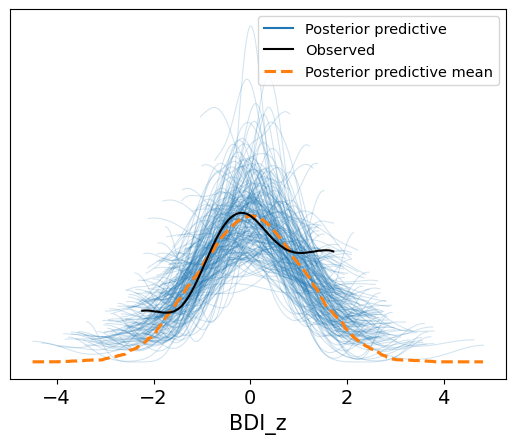

In [18]:
# Plot posterior predictive density 
import pymc as pm
import arviz as az
import numpy as np

# idata_grp1 was returned by pm.sample(...)
with model_grp1:
    # Draw posterior predictive samples for the observed node
    idata_grp1 = pm.sample_posterior_predictive(
        idata_grp1,                 # pass the fit
        var_names=["BDI_z"],        # the observed RV name
        random_seed=123,
        extend_inferencedata=True,  # add to idata_grp1.posterior_predictive
    )

# Quick PPC plot (overlayed densities / ECDFs)
az.plot_ppc(
    idata_grp1,
    data_pairs={"BDI_z": "BDI_z"},  # map obs name -> ppd name
    num_pp_samples=200,             # fewer curves for readability
)

C:\Users\kaank\AppData\Local\Temp\ipykernel_19700\3407715707.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_pred, hdi_prob=0.95)  # 95% credible band


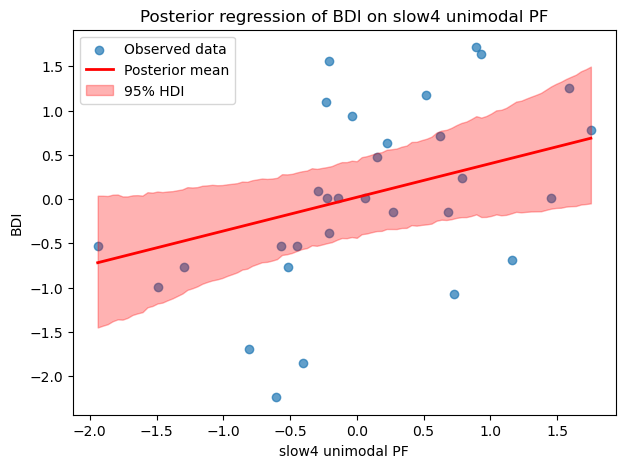

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# Extract posterior draws for intercept and the slope of interest
posterior = idata_grp1.posterior

intercept_draws = posterior["Intercept"].stack(sample=("chain","draw")).values
slope_draws = posterior["b"].sel(term="MF_unimodal_adj_zHC").stack(sample=("chain","draw")).values

# Observed predictor and outcome
x_obs = bp_adj_subject_devs["MF_unimodal_adj_zHC"].values
y_obs = bp_adj_subject_devs["z_BDI"].values

# Define a grid of x for prediction
x_grid = np.linspace(x_obs.min(), x_obs.max(), 100)

# For each posterior sample, compute regression line
y_pred = intercept_draws[:, None] + slope_draws[:, None] * x_grid[None, :]

# Summarize posterior predictions
y_mean = y_pred.mean(axis=0)
hdi = az.hdi(y_pred, hdi_prob=0.95)  # 95% credible band

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.scatter(x_obs, y_obs, alpha=0.7, label="Observed data")

plt.plot(x_grid, y_mean, color="red", lw=2, label="Posterior mean")
plt.fill_between(x_grid, hdi[:,0], hdi[:,1], color="red", alpha=0.3, label="95% HDI")

plt.xlabel("slow4 unimodal PF")
plt.ylabel("BDI")
plt.title("Posterior regression of BDI on slow4 unimodal PF")
plt.legend()
plt.show()
